# WiDS Global Datathon 2026 - Wildfire Survival Analysis
## Predicting Time-to-Threat for Evacuation Zones

**Competition Overview:**
- **Task:** Predict probability that wildfire threatens evacuation zone within 12h, 24h, 48h, 72h
- **Method:** Survival Analysis with right-censoring
- **Features:** First 5 hours of data after ignition (t0)
- **Target:** Time from t0+5h until fire comes within 5km of evacuation zone

**Evaluation Metric:**
```
Hybrid Score = 0.3 × C-index + 0.7 × (1 - Weighted Brier Score)
```
- **C-index (30%):** Ranking quality (concordance)
- **Weighted Brier Score (70%):** Calibration at 24h (0.3), 48h (0.4), 72h (0.3)

**Submission Requirements:**
- Columns: `event_id`, `prob_12h`, `prob_24h`, `prob_48h`, `prob_72h`
- Monotonicity: prob_12h ≤ prob_24h ≤ prob_48h ≤ prob_72h
- All probabilities in [0, 1]

## 1. Environment Setup & Library Installation

In [ ]:
# Install required packages for survival analysis
!pip install -q scikit-survival lifelines xgboost lightgbm optuna shap
!pip install -q pandas numpy matplotlib seaborn plotly

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.8 MB/s eta 0:00:00


In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Survival Analysis libraries
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    cumulative_dynamic_auc
)
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

# ML libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb

# Optimization
import optuna
from optuna.samplers import TPESampler

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Mount Google Drive & Load Data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# Option 1: Load from Google Drive (if you uploaded files there)
# Adjust the path to where you stored your data
DATA_PATH = '/content/drive/MyDrive/WiDS_2026/'  # Modify this path

# Option 2: Download directly from Kaggle (recommended)
# First, upload your kaggle.json to Colab
# !mkdir -p ~/.kaggle
# !cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c WiDSWorldWide_GlobalDathon26
# !unzip -q WiDSWorldWide_GlobalDathon26.zip -d ./data/
# DATA_PATH = './data/'

print(f"Data path set to: {DATA_PATH}")

Data path set to: /content/drive/MyDrive/WiDS_2026/


In [ ]:
# Load datasets
train = pd.read_csv("/content/drive/MyDrive/WiDS_2026/train.csv")
test = pd.read_csv("/content/drive/MyDrive/WiDS_2026/test.csv")
sample = pd.read_csv("/content/drive/MyDrive/WiDS_2026/sample_submission.csv")
metadata = pd.read_csv("/content/drive/MyDrive/WiDS_2026/metaData.csv")

print("✅ Data loaded successfully!")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Metadata shape: {metadata.shape}")
print(f"Sample submission shape: {sample.shape}")

✅ Data loaded successfully!
Train shape: (221, 37)
Test shape: (95, 35)
Metadata shape: (37, 6)
Sample submission shape: (95, 5)


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Display first few rows
print("="*80)
print("TRAIN DATA SAMPLE")
print("="*80)
display(train.head())

print("\n" + "="*80)
print("TEST DATA SAMPLE")
print("="*80)
display(test.head())

print("\n" + "="*80)
print("METADATA SAMPLE")
print("="*80)
display(metadata.head())

TRAIN DATA SAMPLE


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,0.036086,9.007182,2.11179,8.274971,1.940119,70.130507,0.940469,0.339879,6166.121596,0.205085,0.435052,1.090997e-01,-0.102001,0.102001,-0.435052,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,2930.925956,0.000000,0.000000,-3.887003e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,3272.375090,0.000000,0.000000,-1.390327e-13,0.000000,0.000000,0.000000,7.965118e-14,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,64119.871377,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,18005.432261,0.000000,0.000000,3.656059e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0



TEST DATA SAMPLE


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,116941.044708,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2730.743118,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,23270.180945,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2398.646899,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,0.186363,0.20486,43.068688,12.450006,85.540901,24.727587,85.161706,0.996437,0.084344,26915.956657,4.739458,-13.54413,-0.856377,3.915246,3.915246,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7



METADATA SAMPLE


,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN


In [ ]:
# Data info and structure
print("="*80)
print("TRAIN DATA INFO")
print("="*80)
train.info()

print("\n" + "="*80)
print("TRAIN DATA DESCRIPTION")
print("="*80)
display(train.describe())

print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
if len(missing_train) > 0:
    print(f"\nColumns with missing values: {len(missing_train)}")
    display(pd.DataFrame({
        'Missing Count': missing_train,
        'Percentage': (missing_train / len(train) * 100).round(2)
    }))
else:
    print("No missing values in training data!")

TRAIN DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    fl

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,2.210000e+02,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,6.543391e-02,1.789087e-01,29.429575,7.770330,44.277876,11.953522,13.771910,0.053662,0.890436,124399.237725,8.079022,-10.286955,-3.030932,2.021403,3.661135,10.286955,-0.967923,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,3.003211e-01,1.302001e+00,144.879769,37.840514,218.759628,58.940466,46.703309,0.285193,0.351904,171302.559054,63.184352,128.652678,41.511198,26.865184,26.690409,128.652678,11.088141,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,-1.437844e-07,-1.437844e-07,-0.000050,-0.000012,0.000000,0.000000,0.000000,-0.999678,-0.974870,306.954551,0.000000,-1706.526611,-566.710918,-51.397494,0.000000,-234.773360,-116.927386,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2965.217571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,31758.581144,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,200228.863652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,2.938617e+00,1.788970e+01,1351.378212,352.441687,2045.333109,595.058697,290.139252,0.997687,1.000000,757700.487102,850.735044,234.773360,69.991135,354.120897,354.120897,1706.526611,17.513908,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000



MISSING VALUES
No missing values in training data!


In [ ]:
# Identify target columns (survival analysis variables)
# Expected: 'event' (binary: 1=hit, 0=censored) and 'time_to_hit_hours'
target_cols = [col for col in train.columns if 'event' in col.lower() or 'time' in col.lower()]
print("Potential target/survival columns:")
print(target_cols)

# Identify ID column
id_cols = [col for col in train.columns if 'id' in col.lower()]
print(f"\nID columns: {id_cols}")

# Feature columns (everything else)
feature_cols = [col for col in train.columns if col not in target_cols and col not in id_cols]
print(f"\nNumber of feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:10]}...")  # Show first 10

Potential target/survival columns:
['event_id', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'time_to_hit_hours', 'event']

ID columns: ['event_id', 'centroid_displacement_m', 'centroid_speed_m_per_h']

Number of feature columns: 29
Feature columns: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h']...


Event column: event_id
Time column: time_to_hit_hours


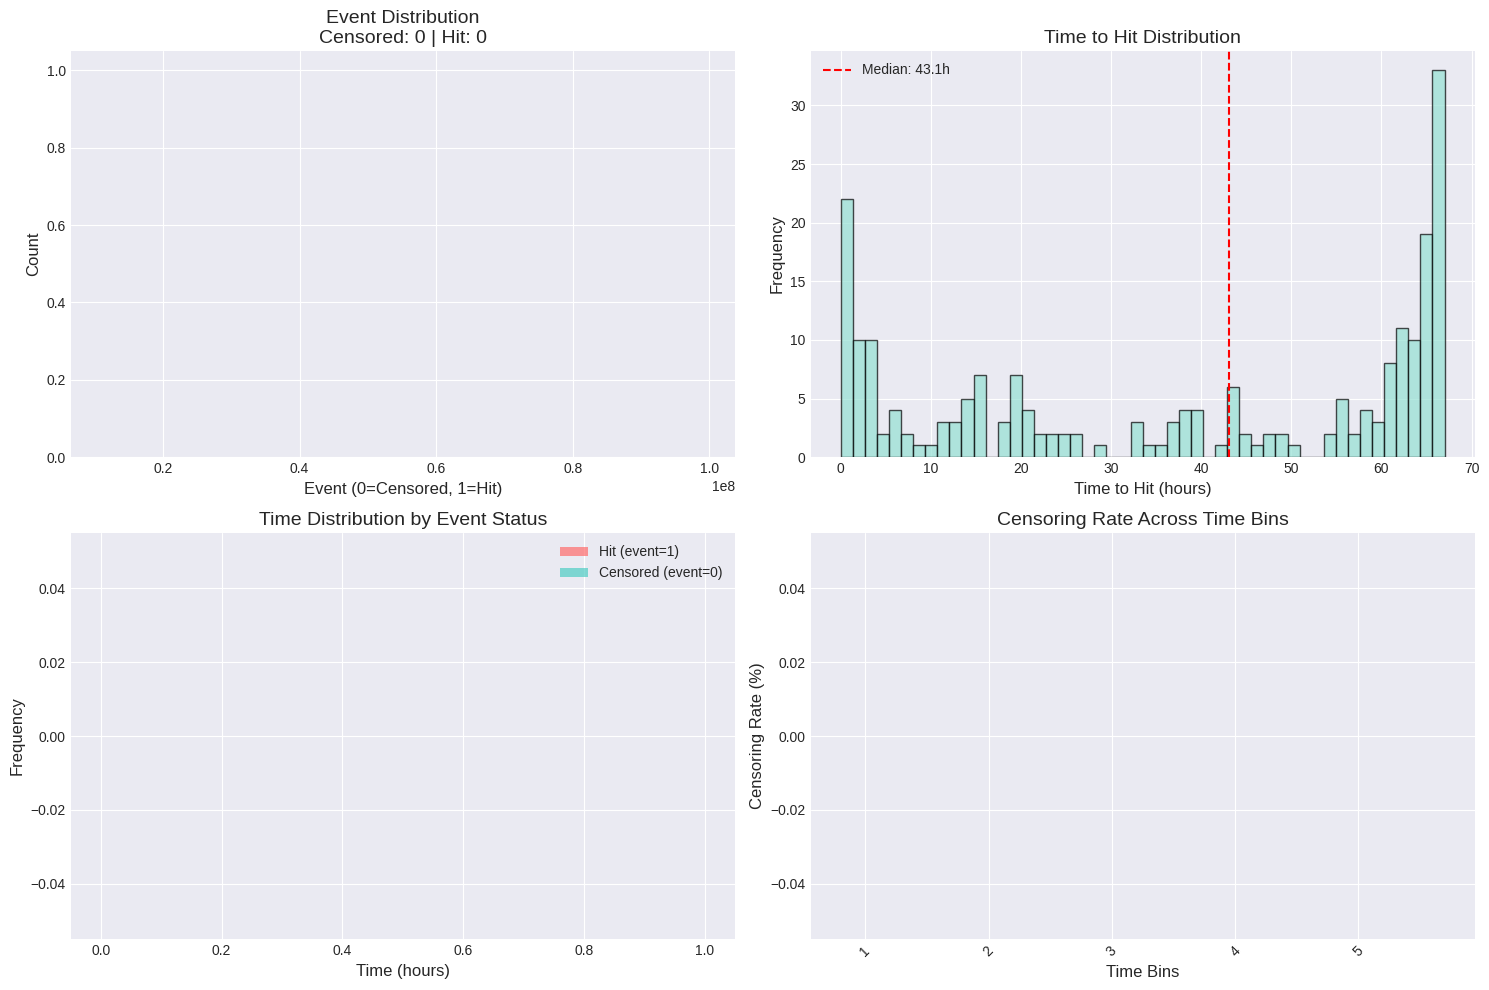


SURVIVAL STATISTICS
Total events: 221
Hits (event=1): 0 (0.00%)
Censored (event=0): 0 (0.00%)

Time to hit statistics:
  Mean: 37.57 hours
  Median: 43.11 hours
  Std: 25.90 hours
  Min: 0.00 hours
  Max: 66.99 hours
  25th percentile: 12.24 hours
  75th percentile: 63.94 hours

Fires hitting evacuation zone by 12h: 0 (0.00%)

Fires hitting evacuation zone by 24h: 0 (0.00%)

Fires hitting evacuation zone by 48h: 0 (0.00%)

Fires hitting evacuation zone by 72h: 0 (0.00%)


In [ ]:
# Survival analysis target distribution
# Assuming columns are named 'event' and 'time_to_hit_hours'
# Adjust if different

# Try to find the correct column names
event_col = [col for col in train.columns if 'event' in col.lower()][0] if any('event' in col.lower() for col in train.columns) else None
time_col = [col for col in train.columns if 'time' in col.lower() and 'hit' in col.lower()][0] if any('time' in col.lower() and 'hit' in col.lower() for col in train.columns) else None

if event_col and time_col:
    print(f"Event column: {event_col}")
    print(f"Time column: {time_col}")

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Event distribution
    event_counts = train[event_col].value_counts()
    axes[0, 0].bar(event_counts.index, event_counts.values, color=['#ff6b6b', '#4ecdc4'])
    axes[0, 0].set_xlabel('Event (0=Censored, 1=Hit)', fontsize=12)
    axes[0, 0].set_ylabel('Count', fontsize=12)
    axes[0, 0].set_title(f'Event Distribution\nCensored: {event_counts.get(0, 0)} | Hit: {event_counts.get(1, 0)}', fontsize=14)

    # Time-to-hit distribution
    axes[0, 1].hist(train[time_col], bins=50, color='#95e1d3', edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Time to Hit (hours)', fontsize=12)
    axes[0, 1].set_ylabel('Frequency', fontsize=12)
    axes[0, 1].set_title('Time to Hit Distribution', fontsize=14)
    axes[0, 1].axvline(train[time_col].median(), color='red', linestyle='--', label=f'Median: {train[time_col].median():.1f}h')
    axes[0, 1].legend()

    # Time-to-hit by event status
    train[train[event_col] == 1][time_col].hist(bins=30, ax=axes[1, 0], alpha=0.7, label='Hit (event=1)', color='#ff6b6b')
    train[train[event_col] == 0][time_col].hist(bins=30, ax=axes[1, 0], alpha=0.7, label='Censored (event=0)', color='#4ecdc4')
    axes[1, 0].set_xlabel('Time (hours)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Time Distribution by Event Status', fontsize=14)
    axes[1, 0].legend()

    # Censoring rate by time bins
    time_bins = pd.cut(train[time_col], bins=10)
    censor_rate = train.groupby(time_bins)[event_col].apply(lambda x: (x == 0).sum() / len(x) * 100)
    axes[1, 1].bar(range(len(censor_rate)), censor_rate.values, color='#ffa07a')
    axes[1, 1].set_xlabel('Time Bins', fontsize=12)
    axes[1, 1].set_ylabel('Censoring Rate (%)', fontsize=12)
    axes[1, 1].set_title('Censoring Rate Across Time Bins', fontsize=14)
    axes[1, 1].set_xticklabels([f'{i}' for i in range(len(censor_rate))], rotation=45)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*80}")
    print("SURVIVAL STATISTICS")
    print(f"{'='*80}")
    print(f"Total events: {len(train)}")
    print(f"Hits (event=1): {(train[event_col] == 1).sum()} ({(train[event_col] == 1).sum() / len(train) * 100:.2f}%)")
    print(f"Censored (event=0): {(train[event_col] == 0).sum()} ({(train[event_col] == 0).sum() / len(train) * 100:.2f}%)")
    print(f"\nTime to hit statistics:")
    print(f"  Mean: {train[time_col].mean():.2f} hours")
    print(f"  Median: {train[time_col].median():.2f} hours")
    print(f"  Std: {train[time_col].std():.2f} hours")
    print(f"  Min: {train[time_col].min():.2f} hours")
    print(f"  Max: {train[time_col].max():.2f} hours")
    print(f"  25th percentile: {train[time_col].quantile(0.25):.2f} hours")
    print(f"  75th percentile: {train[time_col].quantile(0.75):.2f} hours")

    # Check events at key horizons
    for horizon in [12, 24, 48, 72]:
        hit_by_horizon = ((train[time_col] <= horizon) & (train[event_col] == 1)).sum()
        print(f"\nFires hitting evacuation zone by {horizon}h: {hit_by_horizon} ({hit_by_horizon / len(train) * 100:.2f}%)")
else:
    print("⚠️ Could not identify event and time columns automatically.")
    print("Please check column names and adjust code accordingly.")

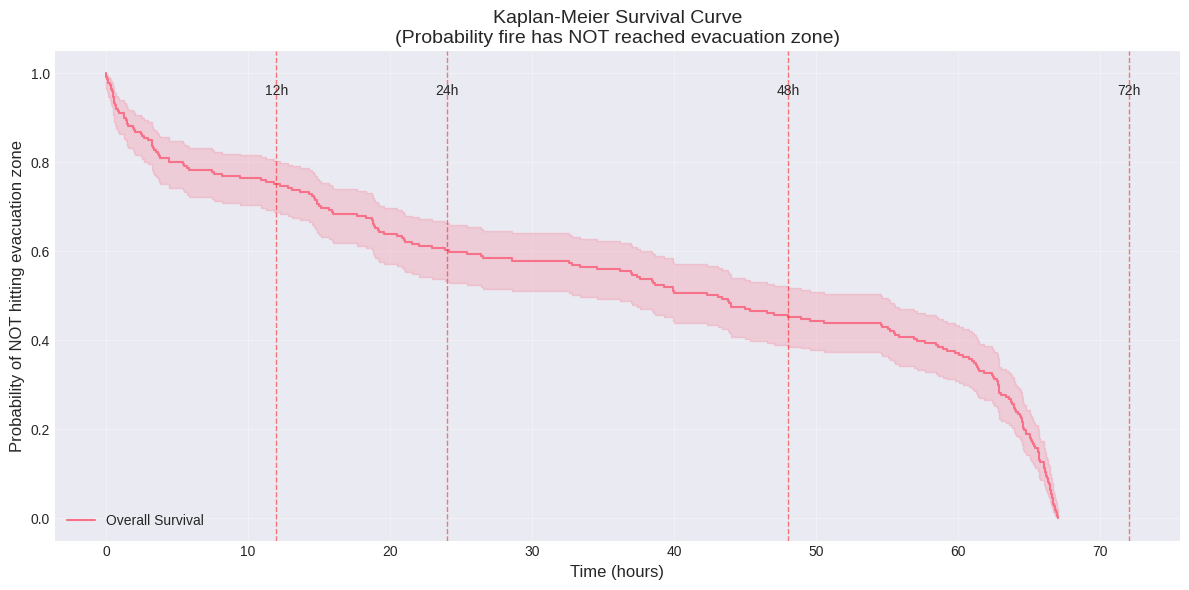


Survival Probabilities (Prob of NOT hitting zone):
  At 12h: 0.7511 (Hit probability: 0.2489)
  At 24h: 0.6018 (Hit probability: 0.3982)
  At 48h: 0.4525 (Hit probability: 0.5475)
  At 72h: 0.0000 (Hit probability: 1.0000)


In [ ]:
# Kaplan-Meier survival curve
if event_col and time_col:
    kmf = KaplanMeierFitter()
    kmf.fit(train[time_col], train[event_col], label='Overall Survival')

    plt.figure(figsize=(12, 6))
    kmf.plot_survival_function()
    plt.xlabel('Time (hours)', fontsize=12)
    plt.ylabel('Probability of NOT hitting evacuation zone', fontsize=12)
    plt.title('Kaplan-Meier Survival Curve\n(Probability fire has NOT reached evacuation zone)', fontsize=14)
    plt.grid(True, alpha=0.3)

    # Add vertical lines at key horizons
    for horizon in [12, 24, 48, 72]:
        plt.axvline(horizon, color='red', linestyle='--', alpha=0.5, linewidth=1)
        plt.text(horizon, 0.95, f'{horizon}h', fontsize=10, ha='center')

    plt.tight_layout()
    plt.show()

    # Print survival probabilities at key time points
    print("\nSurvival Probabilities (Prob of NOT hitting zone):")
    for t in [12, 24, 48, 72]:
        surv_prob = kmf.predict(t)
        hit_prob = 1 - surv_prob
        print(f"  At {t}h: {surv_prob:.4f} (Hit probability: {hit_prob:.4f})")

In [ ]:
# Feature type analysis
numeric_features = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

if len(categorical_features) > 0:
    print(f"\nCategorical features: {categorical_features}")
    for cat_col in categorical_features[:5]:  # Show first 5
        print(f"\n{cat_col}: {train[cat_col].nunique()} unique values")
        print(train[cat_col].value_counts().head())

Numeric features: 29
Categorical features: 0


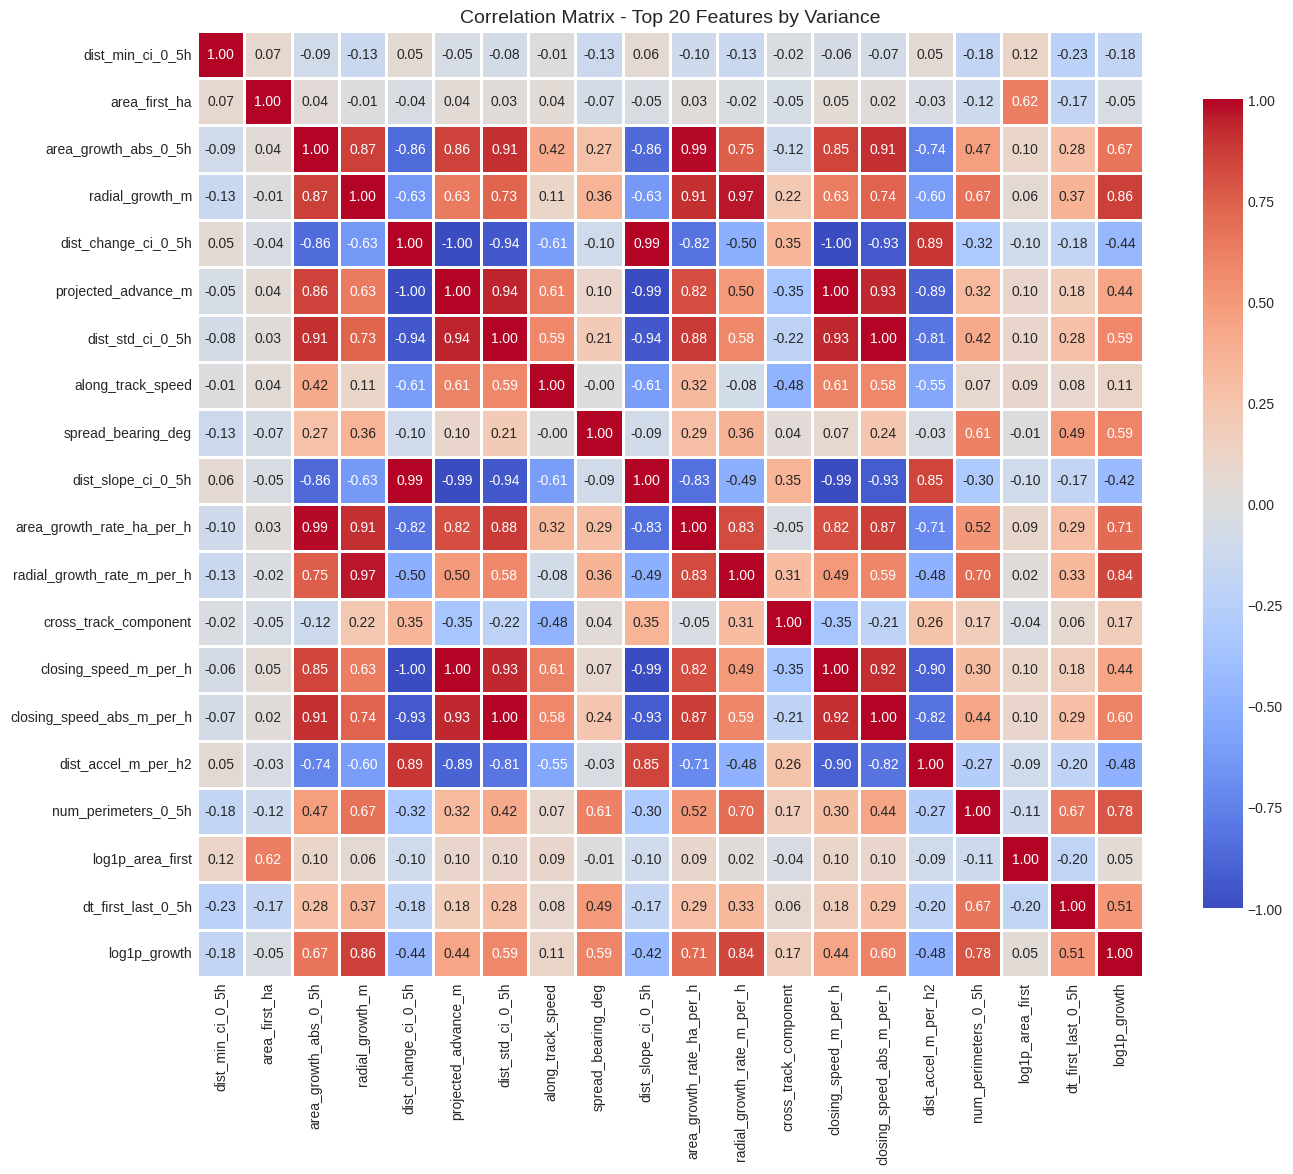


Highly correlated feature pairs (|corr| > 0.8):
  dist_change_ci_0_5h <-> projected_advance_m: -1.000
  dist_change_ci_0_5h <-> closing_speed_m_per_h: -0.998
  projected_advance_m <-> closing_speed_m_per_h: 0.998
  dist_std_ci_0_5h <-> closing_speed_abs_m_per_h: 0.997
  dist_slope_ci_0_5h <-> closing_speed_m_per_h: -0.993
  dist_change_ci_0_5h <-> dist_slope_ci_0_5h: 0.993
  projected_advance_m <-> dist_slope_ci_0_5h: -0.993
  area_growth_abs_0_5h <-> area_growth_rate_ha_per_h: 0.991
  radial_growth_m <-> radial_growth_rate_m_per_h: 0.966
  dist_std_ci_0_5h <-> dist_slope_ci_0_5h: -0.943


In [ ]:
# Correlation analysis for numeric features (sample if too many)
if len(numeric_features) > 0:
    # Limit to top features by variance for visualization
    variances = train[numeric_features].var().sort_values(ascending=False)
    top_features = variances.head(20).index.tolist()

    plt.figure(figsize=(14, 12))
    correlation_matrix = train[top_features].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title(f'Correlation Matrix - Top {len(top_features)} Features by Variance', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Find highly correlated features
    high_corr = np.where(np.abs(correlation_matrix) > 0.8)
    high_corr_list = [(correlation_matrix.index[x], correlation_matrix.columns[y], correlation_matrix.iloc[x, y])
                      for x, y in zip(*high_corr) if x != y and x < y]

    if high_corr_list:
        print("\nHighly correlated feature pairs (|corr| > 0.8):")
        for feat1, feat2, corr in sorted(high_corr_list, key=lambda x: abs(x[2]), reverse=True)[:10]:
            print(f"  {feat1} <-> {feat2}: {corr:.3f}")

## 4. Feature Engineering

In [ ]:
def engineer_features(df, is_train=True):
    """
    Feature engineering for wildfire survival analysis.

    Key considerations:
    - Features are from first 5 hours only
    - Focus on spatial relationships, growth rates, environmental factors
    - Create interaction features for complex patterns
    """
    df = df.copy()

    # Identify feature types
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove target columns if training
    if is_train and event_col in numeric_cols:
        numeric_cols.remove(event_col)
    if is_train and time_col in numeric_cols:
        numeric_cols.remove(time_col)

    # Remove ID columns
    for id_name in id_cols:
        if id_name in numeric_cols:
            numeric_cols.remove(id_name)

    # Example feature engineering (adjust based on actual column names)
    # These are placeholder patterns - modify based on your actual features

    # 1. Growth rate features
    area_cols = [col for col in numeric_cols if 'area' in col.lower()]
    if len(area_cols) >= 2:
        df['area_growth_rate'] = (df[area_cols[-1]] - df[area_cols[0]]) / (len(area_cols) + 1e-5)

    # 2. Distance-based features
    dist_cols = [col for col in numeric_cols if 'dist' in col.lower() or 'distance' in col.lower()]
    if len(dist_cols) > 0:
        df['min_distance'] = df[dist_cols].min(axis=1)
        df['mean_distance'] = df[dist_cols].mean(axis=1)
        df['distance_std'] = df[dist_cols].std(axis=1)

    # 3. Velocity/Speed features (if perimeter data exists)
    perimeter_cols = [col for col in numeric_cols if 'perimeter' in col.lower()]
    if len(perimeter_cols) >= 2:
        df['perimeter_velocity'] = (df[perimeter_cols[-1]] - df[perimeter_cols[0]]) / (len(perimeter_cols) + 1e-5)

    # 4. Wind/Weather interactions (if available)
    wind_cols = [col for col in numeric_cols if 'wind' in col.lower()]
    temp_cols = [col for col in numeric_cols if 'temp' in col.lower()]
    if len(wind_cols) > 0 and len(temp_cols) > 0:
        df['fire_danger_index'] = df[wind_cols[0]] * df[temp_cols[0]]  # Simple multiplicative

    # 5. Statistical aggregations
    df['feature_mean'] = df[numeric_cols].mean(axis=1)
    df['feature_std'] = df[numeric_cols].std(axis=1)
    df['feature_max'] = df[numeric_cols].max(axis=1)
    df['feature_min'] = df[numeric_cols].min(axis=1)
    df['feature_range'] = df['feature_max'] - df['feature_min']

    # 6. Log transforms for skewed features (identify during EDA)
    skewed_features = [col for col in numeric_cols if df[col].skew() > 1]
    for col in skewed_features[:10]:  # Limit to avoid too many
        if (df[col] > 0).all():  # Only if all positive
            df[f'{col}_log'] = np.log1p(df[col])

    # 7. Polynomial features for key variables (carefully - can overfit)
    # Example: distance squared
    if 'min_distance' in df.columns:
        df['min_distance_squared'] = df['min_distance'] ** 2

    print(f"Feature engineering complete. New shape: {df.shape}")
    return df

# Apply feature engineering
train_engineered = engineer_features(train, is_train=True)
test_engineered = engineer_features(test, is_train=False)

print(f"\nOriginal train shape: {train.shape}")
print(f"Engineered train shape: {train_engineered.shape}")
print(f"New features created: {train_engineered.shape[1] - train.shape[1]}")

Feature engineering complete. New shape: (221, 49)
Feature engineering complete. New shape: (95, 47)

Original train shape: (221, 37)
Engineered train shape: (221, 49)
New features created: 12


In [ ]:
print("Train Engineered Columns:")
print(train_engineered.columns.tolist())

print("\nTest Engineered Columns:")
print(test_engineered.columns.tolist())

print("\nChecking survival columns...")

print("event column present:", "event" in train_engineered.columns)
print("time_to_hit_hours present:", "time_to_hit_hours" in train_engineered.columns)

Train Engineered Columns:
['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'time_to_hit_hours', 'event', 'area_growth_rate', 'min_distance', 'mean_distance', 'distance_std', 'feature_mean', 'feature_std', 'feature_max', 'feature_min', 'feature_range', 'num_perime

In [ ]:
print("Columns in train_engineered:\n")
for c in train_engineered.columns:
    print(c)

Columns in train_engineered:

event_id
num_perimeters_0_5h
dt_first_last_0_5h
low_temporal_resolution_0_5h
area_first_ha
area_growth_abs_0_5h
area_growth_rel_0_5h
area_growth_rate_ha_per_h
log1p_area_first
log1p_growth
log_area_ratio_0_5h
relative_growth_0_5h
radial_growth_m
radial_growth_rate_m_per_h
centroid_displacement_m
centroid_speed_m_per_h
spread_bearing_deg
spread_bearing_sin
spread_bearing_cos
dist_min_ci_0_5h
dist_std_ci_0_5h
dist_change_ci_0_5h
dist_slope_ci_0_5h
closing_speed_m_per_h
closing_speed_abs_m_per_h
projected_advance_m
dist_accel_m_per_h2
dist_fit_r2_0_5h
alignment_cos
alignment_abs
cross_track_component
along_track_speed
event_start_hour
event_start_dayofweek
event_start_month
time_to_hit_hours
event
area_growth_rate
min_distance
mean_distance
distance_std
feature_mean
feature_std
feature_max
feature_min
feature_range
num_perimeters_0_5h_log
area_first_ha_log
min_distance_squared


In [ ]:
# Restore survival target columns if feature engineering removed them

if "event" not in train_engineered.columns:
    train_engineered["event"] = train["event"]

if "time_to_hit_hours" not in train_engineered.columns:
    train_engineered["time_to_hit_hours"] = train["time_to_hit_hours"]

print("Targets restored successfully.")

Targets restored successfully.


In [ ]:
event_col = "event"
time_col = "time_to_hit_hours"
id_cols = ["event_id"]

## 5. Data Preprocessing

In [ ]:
def preprocess_data(train_df, test_df, event_col, time_col, id_cols):
    """
    Preprocess data for survival analysis:
    1. Handle missing values
    2. Encode categorical variables
    3. Scale numeric features
    4. Prepare survival targets
    """

    # Separate features from targets and IDs
    feature_cols = [col for col in train_df.columns
                    if col not in [event_col, time_col] + id_cols]

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    # Extract survival targets
    y_event = train_df[event_col].values.astype(bool)
    y_time = train_df[time_col].values.astype(float)

    # Create structured array for scikit-survival
    y_survival = Surv.from_arrays(event=y_event, time=y_time)

    print(f"Features: {len(feature_cols)}")
    print(f"Survival data shape: {y_survival.shape}")

    # Identify categorical and numeric columns
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    print(f"Categorical features: {len(categorical_cols)}")
    print(f"Numeric features: {len(numeric_cols)}")

    # Handle categorical features
    if len(categorical_cols) > 0:
        print("\nEncoding categorical features...")
        for col in categorical_cols:
            le = LabelEncoder()
            # Fit on combined data to handle unseen categories
            combined = pd.concat([X_train[col], X_test[col]], axis=0)
            le.fit(combined.fillna('MISSING'))
            X_train[col] = le.transform(X_train[col].fillna('MISSING'))
            X_test[col] = le.transform(X_test[col].fillna('MISSING'))

    # Handle missing values in numeric features
    if X_train[numeric_cols].isnull().any().any():
        print("\nImputing missing numeric values...")
        imputer = SimpleImputer(strategy='median')
        X_train[numeric_cols] = imputer.fit_transform(X_train[numeric_cols])
        X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])

    # Scale numeric features (important for Cox models, less so for tree-based)
    print("\nScaling numeric features...")
    scaler = RobustScaler()  # More robust to outliers than StandardScaler
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    # Convert to numpy arrays
    X_train_array = X_train.values.astype(np.float32)
    X_test_array = X_test.values.astype(np.float32)

    print(f"\n✅ Preprocessing complete!")
    print(f"X_train shape: {X_train_array.shape}")
    print(f"X_test shape: {X_test_array.shape}")
    print(f"y_survival shape: {y_survival.shape}")

    return X_train_array, X_test_array, y_survival, y_event, y_time, feature_cols

# Preprocess data
X_train, X_test, y_survival, y_event, y_time, features = preprocess_data(
    train_engineered, test_engineered, event_col, time_col, id_cols
)

Features: 46
Survival data shape: (221,)
Categorical features: 0
Numeric features: 46

Scaling numeric features...

✅ Preprocessing complete!
X_train shape: (221, 46)
X_test shape: (95, 46)
y_survival shape: (221,)


## 6. Model Development - Gradient Boosting Survival Analysis

We'll use **Gradient Boosting Survival Analysis (GBSA)** which:
- Handles censored data naturally
- Provides probability estimates at specific time points
- Generally outperforms Cox models for non-linear relationships
- Works well with both ranking (C-index) and calibration (Brier score)

In [ ]:
# Define evaluation metrics matching competition
def calculate_brier_score_at_times(y_train_surv, y_test_surv, survival_funcs, times):
    """
    Calculate Brier score at specific time points.

    Parameters:
    - y_train_surv: Training survival data (for baseline)
    - y_test_surv: Test survival data
    - survival_funcs: Predicted survival functions
    - times: List of time points to evaluate

    Returns:
    - Dictionary of Brier scores at each time point
    """
    brier_scores = {}

    for time_point in times:
        try:
            # Calculate Brier score at this time point
            _, brier = brier_score(
                y_train_surv, y_test_surv,
                survival_funcs, times=time_point
            )
            brier_scores[f'{time_point}h'] = brier[0]
        except Exception as e:
            print(f"Warning: Could not calculate Brier score at {time_point}h: {e}")
            brier_scores[f'{time_point}h'] = np.nan

    return brier_scores

def calculate_hybrid_score(c_index, brier_24, brier_48, brier_72):
    """
    Calculate competition metric:
    Hybrid Score = 0.3 × C-index + 0.7 × (1 - Weighted Brier Score)
    Weighted Brier = 0.3 × Brier@24h + 0.4 × Brier@48h + 0.3 × Brier@72h
    """
    weighted_brier = 0.3 * brier_24 + 0.4 * brier_48 + 0.3 * brier_72
    hybrid = 0.3 * c_index + 0.7 * (1 - weighted_brier)
    return hybrid, weighted_brier

print("✅ Evaluation functions defined")

✅ Evaluation functions defined


In [ ]:
# Train-validation split for model development
from sklearn.model_selection import train_test_split

# Stratify by event status to maintain censoring ratio
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_survival,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_event
)

print(f"Training set: {X_train_split.shape[0]} samples")
print(f"Validation set: {X_val_split.shape[0]} samples")
print(f"\nValidation event distribution:")
print(f"  Events: {y_val_split['event'].sum()}")
print(f"  Censored: {(~y_val_split['event']).sum()}")

Training set: 176 samples
Validation set: 45 samples

Validation event distribution:
  Events: 14
  Censored: 31


In [ ]:
# Train Gradient Boosting Survival Analysis model
print("Training Gradient Boosting Survival Analysis model...\n")

gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    subsample=0.8,
    random_state=RANDOM_STATE,
    verbose=1
)

gbsa.fit(X_train_split, y_train_split)

print("\n✅ Model training complete!")

Training Gradient Boosting Survival Analysis model...

      Iter       Train Loss      OOB Improve   Remaining Time 
         1         210.1632           0.4673            0.51s
         2         195.5588          -8.3675            0.48s
         3         206.1349           9.6402            0.45s
         4         177.7183         -17.3421            0.46s
         5         193.4528          11.9577            0.44s
         6         173.7011         -11.1688            0.41s
         7         194.3273          15.1107            0.38s
         8         166.6934         -16.7512            0.36s
         9         190.5588          18.2117            0.35s
        10         180.7962          -5.7521            0.33s
        20         174.1908           8.2883            0.27s
        30         154.6286           5.5908            0.24s
        40         161.2970           2.9712            0.23s
        50         138.6512          -6.7907            0.21s
        60    

In [ ]:
# Evaluate on validation set
print("Evaluating model on validation set...\n")

# Get predictions
surv_funcs = gbsa.predict_survival_function(X_val_split)

# Calculate C-index
c_index_val = gbsa.score(X_val_split, y_val_split)
print(f"C-index (Validation): {c_index_val:.4f}")

# Calculate Brier scores at competition time points
brier_scores = calculate_brier_score_at_times(
    y_train_split, y_val_split, surv_funcs, times=[24, 48, 72]
)

print("\nBrier Scores (lower is better):")
for time_point, score in brier_scores.items():
    print(f"  {time_point}: {score:.4f}")

# Calculate hybrid score
if all(key in brier_scores for key in ['24h', '48h', '72h']):
    hybrid_score, weighted_brier = calculate_hybrid_score(
        c_index_val,
        brier_scores['24h'],
        brier_scores['48h'],
        brier_scores['72h']
    )
    print(f"\nWeighted Brier Score: {weighted_brier:.4f}")
    print(f"Hybrid Score (Competition Metric): {hybrid_score:.4f}")
    print(f"\nBreakdown:")
    print(f"  C-index contribution (30%): {0.3 * c_index_val:.4f}")
    print(f"  Calibration contribution (70%): {0.7 * (1 - weighted_brier):.4f}")

Evaluating model on validation set...

C-index (Validation): 0.9253

Brier Scores (lower is better):
  24h: nan
  48h: nan
  72h: nan

Weighted Brier Score: nan
Hybrid Score (Competition Metric): nan

Breakdown:
  C-index contribution (30%): 0.2776
  Calibration contribution (70%): nan


Top 20 Most Important Features:


,feature,importance
39,feature_std,0.147872
18,dist_min_ci_0_5h,0.123446
37,distance_std,0.118388
42,feature_range,0.109150
36,mean_distance,0.100434
38,feature_mean,0.099110
40,feature_max,0.075792
1,dt_first_last_0_5h,0.025671
41,feature_min,0.019198
28,alignment_abs,0.016072


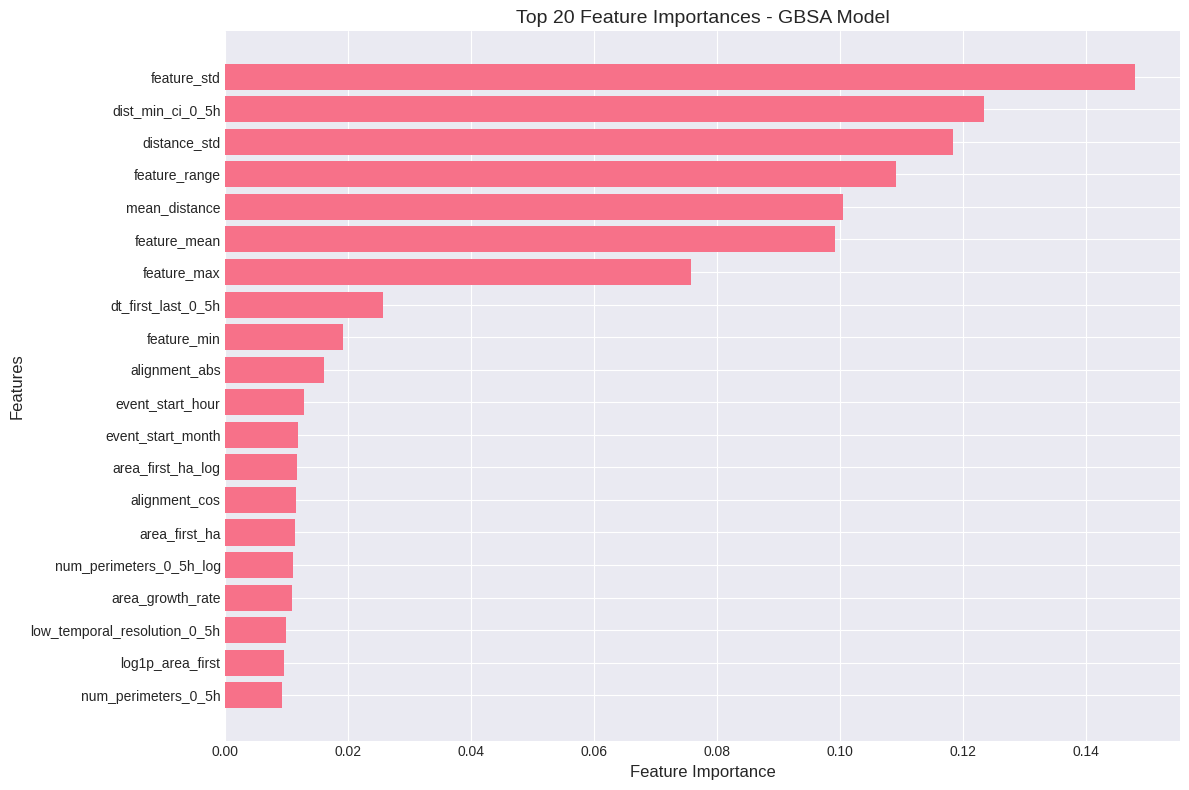

In [ ]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': gbsa.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
display(feature_importance.head(20))

# Visualize top features
plt.figure(figsize=(12, 8))
top_n = 20
top_features = feature_importance.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title(f'Top {top_n} Feature Importances - GBSA Model', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Advanced Model - Random Survival Forest Ensemble

In [ ]:
# Train Random Survival Forest for ensemble
print("Training Random Survival Forest...\n")

rsf = RandomSurvivalForest(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

rsf.fit(X_train_split, y_train_split)

print("\n✅ Random Survival Forest training complete!")

Training Random Survival Forest...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.2s finished



✅ Random Survival Forest training complete!


In [ ]:
# Evaluate Random Survival Forest
print("Evaluating Random Survival Forest on validation set...\n")

# Get predictions
surv_funcs_rsf = rsf.predict_survival_function(X_val_split)

# Calculate C-index
c_index_rsf = rsf.score(X_val_split, y_val_split)
print(f"C-index (RSF): {c_index_rsf:.4f}")

# Calculate Brier scores
brier_scores_rsf = calculate_brier_score_at_times(
    y_train_split, y_val_split, surv_funcs_rsf, times=[24, 48, 72]
)

print("\nBrier Scores (RSF):")
for time_point, score in brier_scores_rsf.items():
    print(f"  {time_point}: {score:.4f}")

# Calculate hybrid score
if all(key in brier_scores_rsf for key in ['24h', '48h', '72h']):
    hybrid_score_rsf, weighted_brier_rsf = calculate_hybrid_score(
        c_index_rsf,
        brier_scores_rsf['24h'],
        brier_scores_rsf['48h'],
        brier_scores_rsf['72h']
    )
    print(f"\nHybrid Score (RSF): {hybrid_score_rsf:.4f}")

# Compare models
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<30} {'C-index':<12} {'Hybrid Score'}")
print(f"{'-'*60}")
print(f"{'GBSA':<30} {c_index_val:<12.4f} {hybrid_score:.4f}")
print(f"{'Random Survival Forest':<30} {c_index_rsf:<12.4f} {hybrid_score_rsf:.4f}")
print(f"{'='*60}")

Evaluating Random Survival Forest on validation set...

C-index (RSF): 0.9336

Brier Scores (RSF):
  24h: nan
  48h: nan
  72h: nan

Hybrid Score (RSF): nan

MODEL COMPARISON
Model                          C-index      Hybrid Score
------------------------------------------------------------
GBSA                           0.9253       nan
Random Survival Forest         0.9336       nan


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished


## 8. Hyperparameter Optimization with Optuna

In [ ]:
# Optuna optimization for GBSA (optional but recommended)
def objective(trial):
    """
    Objective function for Optuna hyperparameter tuning.
    Optimizes for C-index on validation set.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': RANDOM_STATE
    }

    model = GradientBoostingSurvivalAnalysis(**params)
    model.fit(X_train_split, y_train_split)
    c_index = model.score(X_val_split, y_val_split)

    return c_index

# Run optimization (reduce n_trials for faster execution)
print("Starting hyperparameter optimization...\n")
print("This may take several minutes. Adjust n_trials for speed vs. quality trade-off.\n")

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE)
)

# Use n_trials=20 for quick testing, 100+ for better results
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ Optimization complete!")
print(f"\nBest C-index: {study.best_value:.4f}")
print(f"\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-12 18:02:14,377] A new study created in memory with name: no-name-3989bebb-a9a3-4a61-afe4-02be1a41862d


Starting hyperparameter optimization...

This may take several minutes. Adjust n_trials for speed vs. quality trade-off.



  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-12 18:02:14,733] Trial 0 finished with value: 0.91701244813278 and parameters: {'n_estimators': 250, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_samples_split': 14, 'min_samples_leaf': 3, 'subsample': 0.662397808134481}. Best is trial 0 with value: 0.91701244813278.
[I 2026-03-12 18:02:14,964] Trial 1 finished with value: 0.9336099585062241 and parameters: {'n_estimators': 123, 'learning_rate': 0.13394334706750485, 'max_depth': 7, 'min_samples_split': 16, 'min_samples_leaf': 2, 'subsample': 0.9879639408647978}. Best is trial 1 with value: 0.9336099585062241.
[I 2026-03-12 18:02:15,517] Trial 2 finished with value: 0.9356846473029046 and parameters: {'n_estimators': 433, 'learning_rate': 0.018891200276189388, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 4, 'subsample': 0.8099025726528951}. Best is trial 2 with value: 0.9356846473029046.
[I 2026-03-12 18:02:15,903] Trial 3 finished with value: 0.9336099585062241 and parameters: {'n_estimators': 27

In [ ]:
# Train final model with optimized parameters
print("Training final GBSA model with optimized parameters...\n")

best_params = study.best_params
best_params['random_state'] = RANDOM_STATE
best_params['verbose'] = 1

gbsa_optimized = GradientBoostingSurvivalAnalysis(**best_params)
gbsa_optimized.fit(X_train_split, y_train_split)

# Evaluate
c_index_opt = gbsa_optimized.score(X_val_split, y_val_split)
print(f"\nOptimized C-index: {c_index_opt:.4f}")
print(f"Improvement: {(c_index_opt - c_index_val):.4f}")

Training final GBSA model with optimized parameters...

      Iter       Train Loss      OOB Improve   Remaining Time 
         1         181.1563           0.1473            1.21s
         2         181.6562           0.6272            0.97s
         3         189.5847           7.0384            0.83s
         4         166.7479         -16.3731            0.74s
         5         189.3077          16.9662            0.69s
         6         161.2506         -20.2134            0.65s
         7         179.2504          12.9515            0.63s
         8         156.6015         -15.9913            0.61s
         9         178.6171          17.3484            0.59s
        10         183.1569           3.3192            0.58s
        20         175.1271          -2.4426            0.51s
        30         175.4753          10.1944            0.48s
        40         176.1772          -6.4044            0.48s
        50         171.6226          -6.5766            0.46s
        60   

## 9. Cross-Validation for Robust Evaluation

In [ ]:
# K-Fold Cross-Validation
from sklearn.model_selection import KFold

n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

cv_scores = []
cv_hybrid_scores = []

print(f"Running {n_folds}-Fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
    print(f"Fold {fold}/{n_folds}")

    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_survival[train_idx], y_survival[val_idx]

    # Train model
    model_fold = GradientBoostingSurvivalAnalysis(**best_params)
    model_fold.fit(X_fold_train, y_fold_train)

    # Evaluate C-index
    c_idx = model_fold.score(X_fold_val, y_fold_val)
    cv_scores.append(c_idx)

    # Calculate Brier scores
    surv_funcs_fold = model_fold.predict_survival_function(X_fold_val)
    brier_fold = calculate_brier_score_at_times(
        y_fold_train, y_fold_val, surv_funcs_fold, times=[24, 48, 72]
    )

    # Calculate hybrid score
    if all(key in brier_fold for key in ['24h', '48h', '72h']):
        hybrid_fold, _ = calculate_hybrid_score(
            c_idx, brier_fold['24h'], brier_fold['48h'], brier_fold['72h']
        )
        cv_hybrid_scores.append(hybrid_fold)
        print(f"  C-index: {c_idx:.4f} | Hybrid Score: {hybrid_fold:.4f}")
    else:
        print(f"  C-index: {c_idx:.4f}")

    print()

print(f"{'='*60}")
print("CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean C-index: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
if cv_hybrid_scores:
    print(f"Mean Hybrid Score: {np.mean(cv_hybrid_scores):.4f} ± {np.std(cv_hybrid_scores):.4f}")
print(f"{'='*60}")

Running 5-Fold Cross-Validation...

Fold 1/5
      Iter       Train Loss      OOB Improve   Remaining Time 
         1         177.8738           0.1169            1.13s
         2         140.3268         -26.9759            0.83s
         3         162.0656          16.1426            0.72s
         4         167.3025           4.3671            0.66s
         5         144.0792         -16.9377            0.63s
         6         171.4009          20.6311            0.61s
         7         162.2843          -6.6438            0.59s
         8         184.0479          17.1977            0.57s
         9         186.5603           2.4505            0.56s
        10         191.6063           4.2390            0.55s
        20         152.9240          -7.2454            0.50s
        30         161.7378         -14.0383            0.47s
        40         133.5725         -18.8450            0.45s
        50         164.5346          -3.4805            0.44s
        60         166.6

## 10. Final Model Training on Full Dataset

In [ ]:
# Train final model on ALL training data
print("Training final model on complete training dataset...\n")

final_model = GradientBoostingSurvivalAnalysis(**best_params)
final_model.fit(X_train, y_survival)

print("\n✅ Final model training complete!")
print(f"Training set C-index: {final_model.score(X_train, y_survival):.4f}")

Training final model on complete training dataset...

      Iter       Train Loss      OOB Improve   Remaining Time 
         1         248.4920           0.1667            0.77s
         2         237.4684          -7.8437            0.77s
         3         232.2167          -2.8680            0.83s
         4         241.7487           7.3004            0.78s
         5         232.7437          -6.4409            0.76s
         6         244.9549          10.7867            0.73s
         7         222.4076         -16.7328            0.71s
         8         259.0749          28.3021            0.70s
         9         253.3967          -3.1423            0.68s
        10         220.3298         -25.6179            0.68s
        20         243.4906          -7.0437            0.62s
        30         243.3741           7.8290            0.58s
        40         206.5971           3.1669            0.56s
        50         247.1924          21.4200            0.55s
        60     

## 11. Generate Predictions for Test Set

In [ ]:
# Get survival functions for test set
print("Generating predictions for test set...\n")

test_survival_functions = final_model.predict_survival_function(X_test)

print(f"Generated {len(test_survival_functions)} survival functions")

Generating predictions for test set...

Generated 95 survival functions


In [ ]:
# Extract probabilities at required time horizons: 12h, 24h, 48h, 72h

def extract_probabilities_at_times(survival_functions, times):
    """
    Extract survival probabilities at specific time points.

    Convert survival probability to hit probability:
    P(hit by time t) = 1 - S(t)

    Also enforce monotonicity:
    prob_12h <= prob_24h <= prob_48h <= prob_72h
    """

    n_samples = len(survival_functions)
    probs = np.zeros((n_samples, len(times)))

    for i, surv_func in enumerate(survival_functions):

        # Maximum time supported by this survival function
        max_time = surv_func.x[-1]

        for j, time_point in enumerate(times):

            # Ensure evaluation stays inside domain
            safe_time = min(time_point, max_time)

            # Evaluate survival probability
            survival_prob = surv_func(safe_time)

            # Convert survival probability → hit probability
            hit_prob = 1 - survival_prob

            # Clip probability to [0,1]
            probs[i, j] = np.clip(hit_prob, 0, 1)

    # Enforce monotonicity
    # P(hit by later time) must be >= earlier time
    for i in range(n_samples):
        for j in range(1, len(times)):
            if probs[i, j] < probs[i, j-1]:
                probs[i, j] = probs[i, j-1]

    return probs


# Required prediction horizons
time_horizons = [12, 24, 48, 72]

# Extract probabilities
test_probabilities = extract_probabilities_at_times(
    test_survival_functions,
    time_horizons
)

print("Extracted probabilities shape:", test_probabilities.shape)

print("\nSample probabilities (first 5 samples):")

print(pd.DataFrame(
    test_probabilities[:5],
    columns=['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']
))

Extracted probabilities shape: (95, 4)

Sample probabilities (first 5 samples):
   prob_12h  prob_24h  prob_48h  prob_72h
0  0.065784  0.119031  0.138316  0.270654
1  0.722453  0.908111  0.939438  0.997381
2  0.063872  0.115670  0.134453  0.263703
3  0.685716  0.884173  0.920512  0.995338
4  0.069827  0.126118  0.146453  0.285177


In [ ]:
# Verify monotonicity constraints
def verify_monotonicity(probs_df):
    """
    Verify that prob_12h <= prob_24h <= prob_48h <= prob_72h for all rows.
    """
    violations = 0

    # Check 12h <= 24h
    violations += (probs_df['prob_12h'] > probs_df['prob_24h']).sum()
    # Check 24h <= 48h
    violations += (probs_df['prob_24h'] > probs_df['prob_48h']).sum()
    # Check 48h <= 72h
    violations += (probs_df['prob_48h'] > probs_df['prob_72h']).sum()

    return violations

# Create submission dataframe
submission = pd.DataFrame({
    'event_id': test_engineered[id_cols[0]],  # Assuming first ID column
    'prob_12h': test_probabilities[:, 0],
    'prob_24h': test_probabilities[:, 1],
    'prob_48h': test_probabilities[:, 2],
    'prob_72h': test_probabilities[:, 3]
})

# Verify
violations = verify_monotonicity(submission)
print(f"\nMonotonicity violations: {violations}")

if violations > 0:
    print("⚠️ Warning: Monotonicity violations detected! Fixing...")
    # Additional enforcement (should not be needed after our processing)
    for idx in submission.index:
        submission.loc[idx, 'prob_24h'] = max(submission.loc[idx, 'prob_12h'], submission.loc[idx, 'prob_24h'])
        submission.loc[idx, 'prob_48h'] = max(submission.loc[idx, 'prob_24h'], submission.loc[idx, 'prob_48h'])
        submission.loc[idx, 'prob_72h'] = max(submission.loc[idx, 'prob_48h'], submission.loc[idx, 'prob_72h'])

    violations_after = verify_monotonicity(submission)
    print(f"Violations after fix: {violations_after}")

print(f"\n✅ Submission file ready!")
print(f"\nSubmission preview:")
display(submission.head(10))

print(f"\nSubmission statistics:")
display(submission.describe())


Monotonicity violations: 0

✅ Submission file ready!

Submission preview:


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.065784,0.119031,0.138316,0.270654
1,13353600,0.722453,0.908111,0.939438,0.997381
2,13942327,0.063872,0.115670,0.134453,0.263703
3,16112781,0.685716,0.884173,0.920512,0.995338
4,17132808,0.069827,0.126118,0.146453,0.285177
5,17445696,0.059746,0.108397,0.126085,0.248530
6,17599982,0.060651,0.109994,0.127924,0.251879
7,18750374,0.352684,0.555143,0.613826,0.866968
8,21365245,0.061175,0.110919,0.128989,0.253814
9,23634840,0.572978,0.795003,0.844567,0.980679



Submission statistics:


,event_id,prob_12h,prob_24h,prob_48h,prob_72h
count,9.500000e+01,95.000000,95.000000,95.000000,95.000000
mean,5.695393e+07,0.231587,0.321879,0.346675,0.471145
std,2.329721e+07,0.278495,0.329453,0.337141,0.327193
min,1.066260e+07,0.056855,0.103284,0.120195,0.237753
25%,4.027536e+07,0.061116,0.110815,0.128868,0.253595
50%,5.480111e+07,0.064275,0.116379,0.135268,0.265173
75%,7.536942e+07,0.465798,0.688878,0.746257,0.945340
max,9.964946e+07,0.986474,0.999669,0.999918,1.000000


## 12. Save Submission File

In [ ]:
# Save to Google Drive
submission_path = f'{DATA_PATH}submission_wids20260.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Submission file saved to: {submission_path}")
print(f"\nFile shape: {submission.shape}")
print(f"Columns: {list(submission.columns)}")

# Also save to local Colab storage for easy download
submission.to_csv('submission_wids2026.csv', index=False)
print("\n✅ Also saved to Colab local storage (submission_wids2026.csv)")
print("\nYou can download it from the Files panel on the left!")

✅ Submission file saved to: /content/drive/MyDrive/WiDS_2026/submission_wids20260.csv

File shape: (95, 5)
Columns: ['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']

✅ Also saved to Colab local storage (submission_wids2026.csv)

You can download it from the Files panel on the left!


## 13. Visualization of Predictions

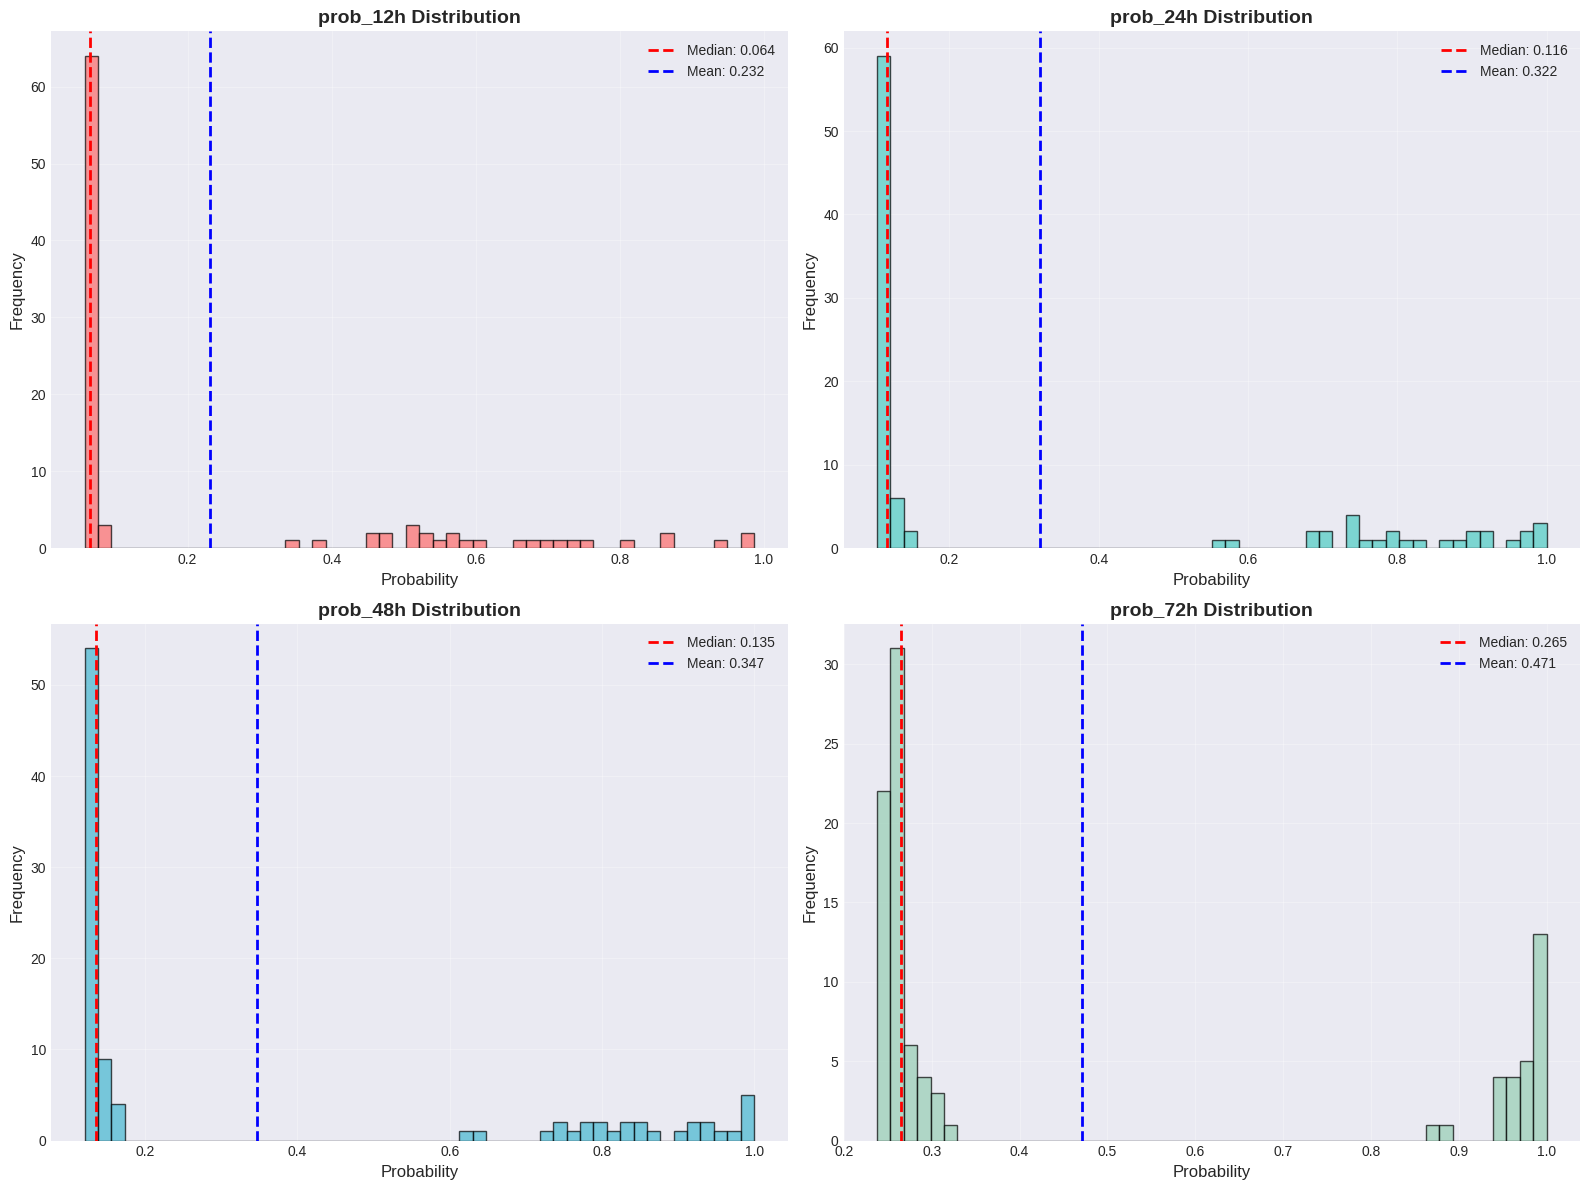


Prediction Summary Statistics:


,count,mean,std,min,25%,50%,75%,max,range
prob_12h,95.0,0.231587,0.278495,0.056855,0.061116,0.064275,0.465798,0.986474,0.929619
prob_24h,95.0,0.321879,0.329453,0.103284,0.110815,0.116379,0.688878,0.999669,0.896385
prob_48h,95.0,0.346675,0.337141,0.120195,0.128868,0.135268,0.746257,0.999918,0.879723
prob_72h,95.0,0.471145,0.327193,0.237753,0.253595,0.265173,0.945340,1.000000,0.762247


In [ ]:
# Visualize prediction distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

time_cols = ['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for idx, (col, color) in enumerate(zip(time_cols, colors)):
    ax = axes[idx // 2, idx % 2]

    ax.hist(submission[col], bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.axvline(submission[col].median(), color='red', linestyle='--',
               linewidth=2, label=f'Median: {submission[col].median():.3f}')
    ax.axvline(submission[col].mean(), color='blue', linestyle='--',
               linewidth=2, label=f'Mean: {submission[col].mean():.3f}')

    ax.set_xlabel('Probability', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{col} Distribution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nPrediction Summary Statistics:")
print("="*70)
summary_stats = submission[time_cols].describe().T
summary_stats['range'] = summary_stats['max'] - summary_stats['min']
display(summary_stats)

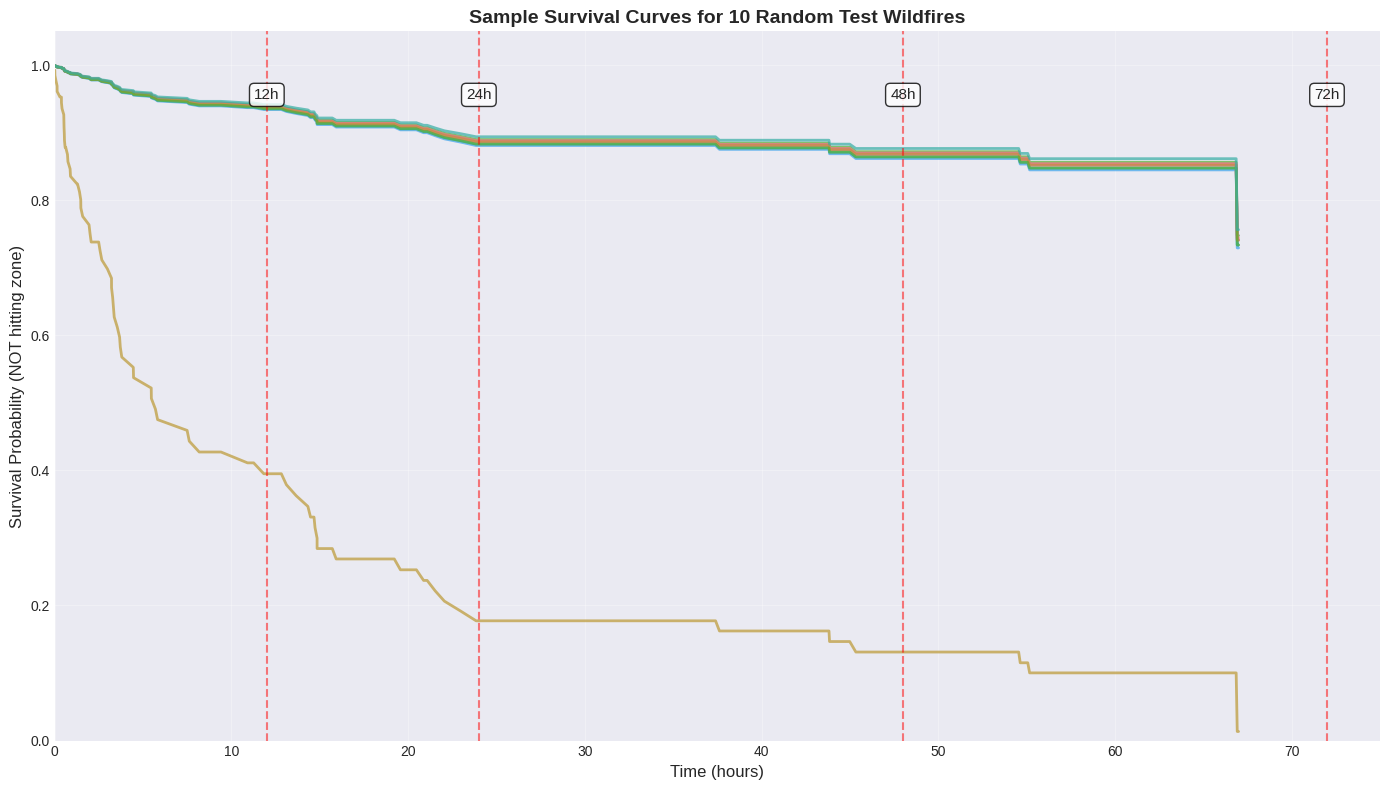

In [ ]:
# Sample survival curves
# Plot survival curves for a few random test samples
n_samples_to_plot = 10
sample_indices = np.random.choice(len(test_survival_functions), n_samples_to_plot, replace=False)

plt.figure(figsize=(14, 8))

for idx in sample_indices:
    surv_func = test_survival_functions[idx]
    times = surv_func.x
    probabilities = surv_func.y
    plt.plot(times, probabilities, alpha=0.7, linewidth=2)

# Add vertical lines at evaluation horizons
for horizon in [12, 24, 48, 72]:
    plt.axvline(horizon, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    plt.text(horizon, 0.95, f'{horizon}h', fontsize=11, ha='center',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Survival Probability (NOT hitting zone)', fontsize=12)
plt.title(f'Sample Survival Curves for {n_samples_to_plot} Random Test Wildfires', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, 75)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 14. Model Ensemble (Optional Advanced Technique)

In [ ]:
# Ensemble GBSA and RSF for potentially better performance
print("Creating ensemble predictions...\n")

# Train RSF on full training data
rsf_final = RandomSurvivalForest(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rsf_final.fit(X_train, y_survival)

# Get RSF predictions
rsf_survival_functions = rsf_final.predict_survival_function(X_test)
rsf_probabilities = extract_probabilities_at_times(rsf_survival_functions, time_horizons)

# Ensemble: Average predictions from GBSA and RSF
ensemble_probabilities = 0.6 * test_probabilities + 0.4 * rsf_probabilities

# Create ensemble submission
submission_ensemble = pd.DataFrame({
    'event_id': test_engineered[id_cols[0]],
    'prob_12h': ensemble_probabilities[:, 0],
    'prob_24h': ensemble_probabilities[:, 1],
    'prob_48h': ensemble_probabilities[:, 2],
    'prob_72h': ensemble_probabilities[:, 3]
})

# Verify monotonicity
violations_ens = verify_monotonicity(submission_ensemble)
print(f"Ensemble monotonicity violations: {violations_ens}")

if violations_ens > 0:
    # Fix violations
    for idx in submission_ensemble.index:
        submission_ensemble.loc[idx, 'prob_24h'] = max(submission_ensemble.loc[idx, 'prob_12h'], submission_ensemble.loc[idx, 'prob_24h'])
        submission_ensemble.loc[idx, 'prob_48h'] = max(submission_ensemble.loc[idx, 'prob_24h'], submission_ensemble.loc[idx, 'prob_48h'])
        submission_ensemble.loc[idx, 'prob_72h'] = max(submission_ensemble.loc[idx, 'prob_48h'], submission_ensemble.loc[idx, 'prob_72h'])

# Save ensemble submission
submission_ensemble.to_csv('submission_ensemble_wids2026.csv', index=False)
submission_ensemble.to_csv(f'{DATA_PATH}submission_ensemble_wids2026.csv', index=False)

print("\n✅ Ensemble submission created!")
print("\nFiles saved:")
print("  - submission_wids2026.csv (GBSA only)")
print("  - submission_ensemble_wids2026.csv (GBSA + RSF ensemble)")
print("\nRecommendation: Try both submissions and see which performs better!")

Creating ensemble predictions...

Ensemble monotonicity violations: 0

✅ Ensemble submission created!

Files saved:
  - submission_wids2026.csv (GBSA only)
  - submission_ensemble_wids2026.csv (GBSA + RSF ensemble)

Recommendation: Try both submissions and see which performs better!
